#### Imports

In [60]:
# local imports
from dist_gen import *

# external imports
import matplotlib.animation as anim
import matplotlib.pyplot as plt
from collections import namedtuple
import numpy as np
#import pandas as pd
#import plasmapy as plas
#import random as rd

#### 1D Particle Simulation

In [78]:
class Electron():
    def __init__(self, x_init, v_init):
        self.x: float = x_init
        self.v: float = v_init
class Ion():
    def __init__(self, x_init, v_init):
        self.x: float = x_init
        self.v: float = v_init

Parameters

In [124]:
N = 5000 # number of particles
x_min, x_max = -10, 10
v_min, v_max = -10, 10
dt = 0.01

def E(x) -> float: # electric field
    return 0

def x_dist(x) -> float:
    return 1

def v_dist(x) -> float:
    return np.e**(-4*(x-6)**2) + np.e**(-4*(x+6)**2)

def accel_from_force(x, v):
    return 0

Initialization and Step Functions

In [119]:
particles: list = []

def init():
    global particles
    particles = []
    for i in range(N):
        particles.append(
            Electron(
                rand_from_dist(x_dist, x_min, x_max),
                rand_from_dist(v_dist, v_min, v_max)
            )
        )

def step(frame):
    global ax
    for p in particles:
        p.v += accel_from_force(p.x, p.v) * dt
        p.x += p.v * dt
        if p.x < x_min:
            p.x += x_max - x_min
        elif p.x > x_max:
            p.x -= x_max - x_min
    ax.set_title("t = " + str(float(f'{frame*dt:.2f}')))
    view = plt.hist2d([p.x for p in particles], [p.v for p in particles], bins=100, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
    return view
    

Creating an Animation

In [125]:
init()

MovieWriter ffmpeg unavailable; using Pillow instead.


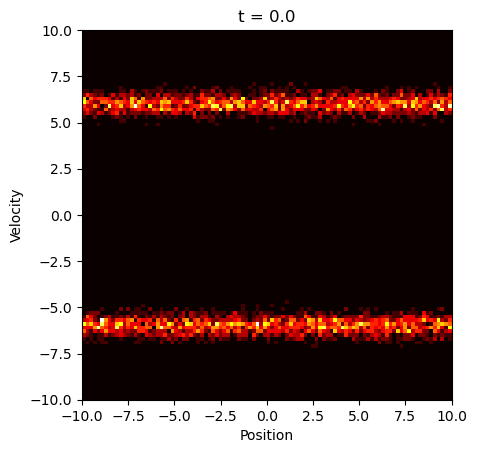

In [126]:
fig, ax = plt.subplots()
view = plt.hist2d([p.x for p in particles], [p.v for p in particles], bins=100, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_box_aspect(1)

ani = anim.FuncAnimation(fig=fig, func=step, frames=120, interval=30)
ani.save("first_sim.gif")

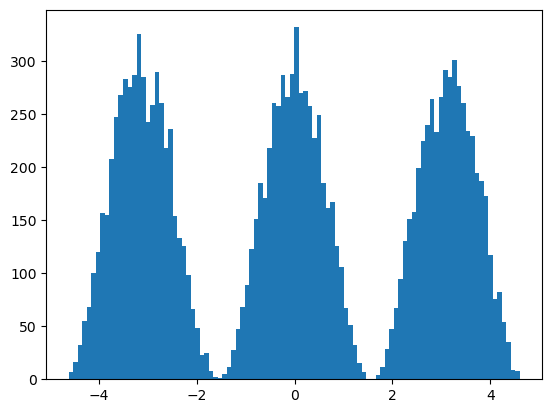

In [5]:
def test_func(x) -> float:
    return np.cos(x)**2

plt.hist(rfd_array(test_func, 15000, [-3*np.pi/2, 3*np.pi/2]), 100);